In [1]:
###-----------------
### Import libraries
###-----------------
from pathlib import Path  # Import Path for file system path operations and management
import numpy as np  # Import NumPy for numerical computations and array operations
import pandas as pd  # Import Pandas for data manipulation and analysis with DataFrames
import matplotlib.pyplot as plt  # Import Matplotlib for creating static, interactive visualizations
import seaborn as sns  # Import Seaborn for statistical data visualization built on Matplotlib
import tensorflow as tf

from sklearn.model_selection import train_test_split  # Import function to split dataset into training and testing subsets
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, mean_squared_error  # Import function to calculate various metric

from collections.abc import Callable  # Type hinting callable objects/functions
from typing import Literal  # Literal type hints to restrict variable values

from sklearn.preprocessing import StandardScaler  # Import for standardizing features (zero mean, unit variance)
from tensorflow.dtensor.python.numpy_util import to_numpy

#from S000.S05z_one_hidden_layer_with_tanh_animation_wip import num_examples
from utils.helper import fn_plot_torch_hist, fn_plot_confusion_matrix, fn_plot_tf_hist # Custom utility

In [2]:
print (fn_plot_torch_hist.__doc__)

None


In [3]:
print (fn_plot_confusion_matrix.__doc__)


    Args:
        y_true: Ground Truth 
        y_pred : Predictions
        labels : labels in a dictonary 
                  {0: 'Goal Keeper', 
                  1: 'Defender', 
                  2: 'Mid-Fielder', 
                  3: 'Forward'}
    
    


In [4]:
###----------------------
### Some basic parameters
###----------------------

# inpDir = Path('..') / '..' / 'input'
# outDir = Path('..') / 'output'
# modelDir = Path('..') / 'models'
# subDir = 'fifa_2019'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
np.random.seed(RANDOM_STATE)
rng = np.random.default_rng(seed = RANDOM_STATE) # Set Random Seed for reproducible  results

EPOCHS = 100 # number of epochs
BATCH_SIZE = 32
ALPHA = 0.001 # learning rate
TEST_SIZE = 0.2

# parameters for Matplotlib
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'x-large',
          'axes.titlesize':'x-large',
          'xtick.labelsize':'x-large',
          'ytick.labelsize':'x-large'
         }

plt.rcParams.update(params)

CMAP = plt.cm.coolwarm
plt.style.use('seaborn-v0_8-darkgrid') # plt.style.use('ggplot')

## Getting Weather Data

In [5]:
data_df = pd.read_csv("../input/weatherHistory.csv")
data_df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [6]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [7]:
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature (C),96453.0,11.932678,9.551546,-21.822222,4.688889,12.0000,18.838889,39.905556
Apparent Temperature (C),96453.0,10.855029,10.696847,-27.716667,2.311111,12.0000,18.838889,39.344444
Humidity,96453.0,0.734899,0.195473,0.000000,0.600000,0.7800,0.890000,1.000000
Wind Speed (km/h),96453.0,10.810640,6.913571,0.000000,5.828200,9.9659,14.135800,63.852600
Wind Bearing (degrees),96453.0,187.509232,107.383428,0.000000,116.000000,180.0000,290.000000,359.000000
Visibility (km),96453.0,10.347325,4.192123,0.000000,8.339800,10.0464,14.812000,16.100000
Loud Cover,96453.0,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
Pressure (millibars),96453.0,1003.235956,116.969906,0.000000,1011.900000,1016.4500,1021.090000,1046.380000


## Basic Hygiene

In [8]:
for col in data_df.columns:
    print(f'Column: {col} - {data_df[col].unique()}')

Column: Formatted Date - ['2006-04-01 00:00:00.000 +0200' '2006-04-01 01:00:00.000 +0200'
 '2006-04-01 02:00:00.000 +0200' ... '2016-09-09 21:00:00.000 +0200'
 '2016-09-09 22:00:00.000 +0200' '2016-09-09 23:00:00.000 +0200']
Column: Summary - ['Partly Cloudy' 'Mostly Cloudy' 'Overcast' 'Foggy'
 'Breezy and Mostly Cloudy' 'Clear' 'Breezy and Partly Cloudy'
 'Breezy and Overcast' 'Humid and Mostly Cloudy' 'Humid and Partly Cloudy'
 'Windy and Foggy' 'Windy and Overcast' 'Breezy and Foggy'
 'Windy and Partly Cloudy' 'Breezy' 'Dry and Partly Cloudy'
 'Windy and Mostly Cloudy' 'Dangerously Windy and Partly Cloudy' 'Dry'
 'Windy' 'Humid and Overcast' 'Light Rain' 'Drizzle' 'Windy and Dry'
 'Dry and Mostly Cloudy' 'Breezy and Dry' 'Rain']
Column: Precip Type - ['rain' 'snow' nan]
Column: Temperature (C) - [ 9.47222222  9.35555556  9.37777778 ... 28.47222222 28.33888889
 30.60555556]
Column: Apparent Temperature (C) - [ 7.38888889  7.22777778  9.37777778 ... 12.14444444  9.73888889
  9.2333333

In [9]:
data_df['datetime'] = pd.to_datetime(data_df['Formatted Date'], utc = True)
data_df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,datetime
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.,2006-03-31 22:00:00+00:00
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.,2006-03-31 23:00:00+00:00
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.,2006-04-01 00:00:00+00:00
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.,2006-04-01 01:00:00+00:00
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.,2006-04-01 02:00:00+00:00


In [10]:
temp_df = data_df[['datetime', 
                   'Temperature (C)', 
                   'Humidity', 
                   'Visibility (km)'
                   ]]
temp_df = temp_df.sort_values('datetime', axis=0, ascending=True)
temp_df = temp_df.reset_index(drop=True)
temp_df.head()

,datetime,Temperature (C),Humidity,Visibility (km)
0,2005-12-31 23:00:00+00:00,0.577778,0.89,9.9820
1,2006-01-01 00:00:00+00:00,1.161111,0.85,9.9015
2,2006-01-01 01:00:00+00:00,1.666667,0.82,9.9015
3,2006-01-01 02:00:00+00:00,1.711111,0.82,9.9015
4,2006-01-01 03:00:00+00:00,1.183333,0.86,9.9015


In [11]:
temp_df = temp_df.rename({'Temperature (C)' : 'temp', 
                          'Humidity':'hum',
                          'Visibility (km)':'viz'
                          }, axis=1)
temp_df.head()

,datetime,temp,hum,viz
0,2005-12-31 23:00:00+00:00,0.577778,0.89,9.9820
1,2006-01-01 00:00:00+00:00,1.161111,0.85,9.9015
2,2006-01-01 01:00:00+00:00,1.666667,0.82,9.9015
3,2006-01-01 02:00:00+00:00,1.711111,0.82,9.9015
4,2006-01-01 03:00:00+00:00,1.183333,0.86,9.9015


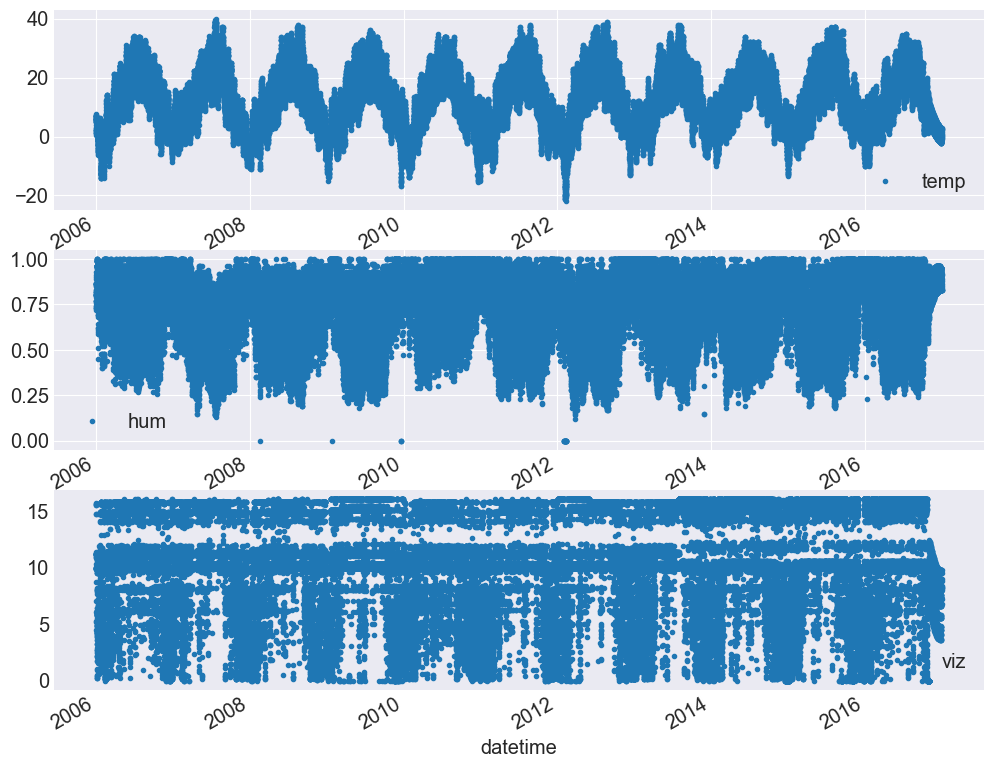

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
ax = axes[0]
temp_df.plot(x='datetime', y='temp', style='.', ax=ax)

ax = axes[1]
temp_df.plot(x='datetime', y='hum', style='.', ax=ax)

ax = axes[2]
temp_df.plot(x='datetime', y='viz', style='.', ax=ax)

ax.grid(False)

In [13]:
num_cols = ['Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)','Pressure (millibars)']
len(num_cols)

6

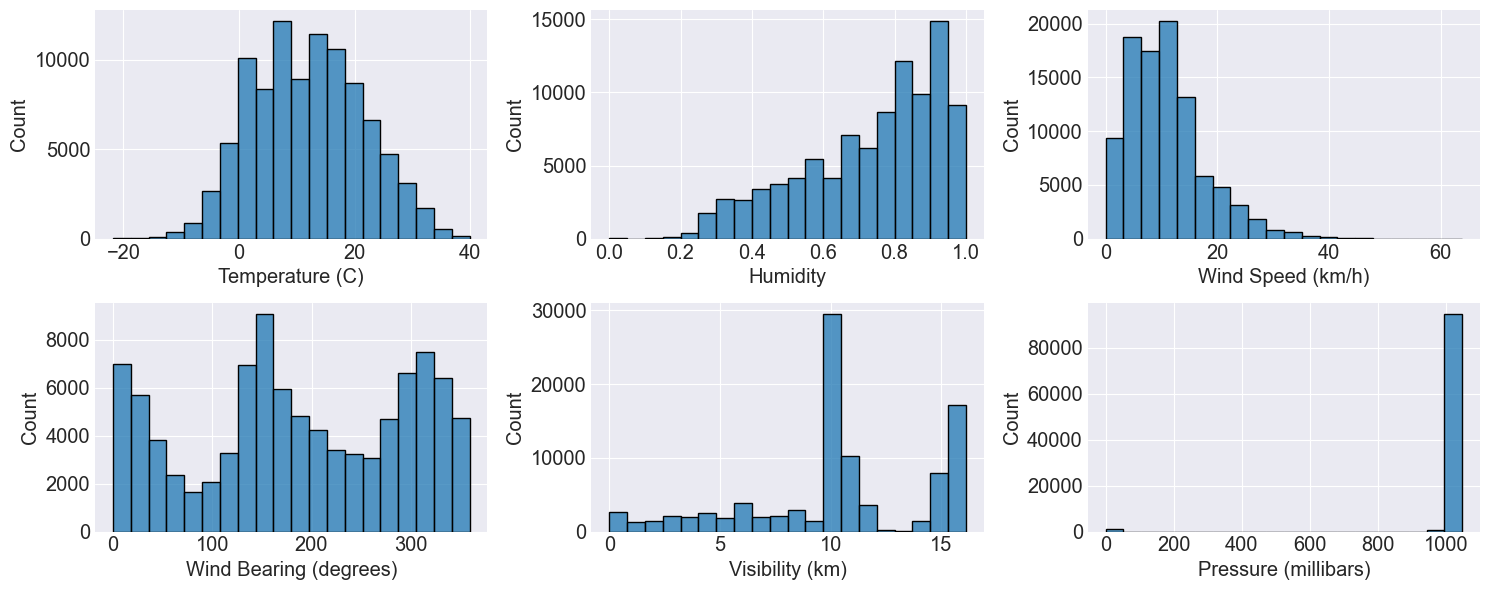

In [14]:
fig, axes = plt.subplots(2,3)
axes = axes.ravel()
for count, col in enumerate(num_cols):
    ax = axes[count]
    sns.histplot(data=data_df, x=col, ax=ax, bins=20)
plt.tight_layout()

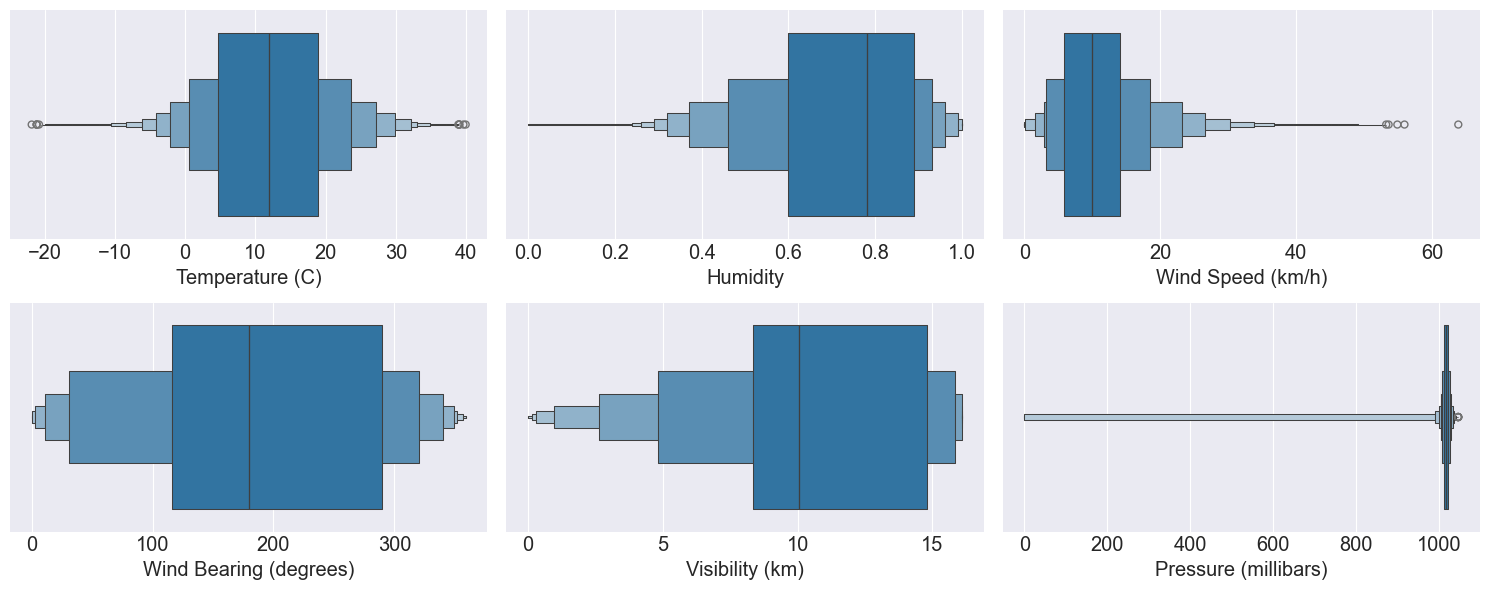

In [15]:
fig, axes = plt.subplots(2,3)
axes = axes.ravel()
for count, col in enumerate(num_cols):
    ax = axes[count]
    sns.boxenplot(data=data_df, x=col, ax=ax)
plt.tight_layout()

<Axes: >

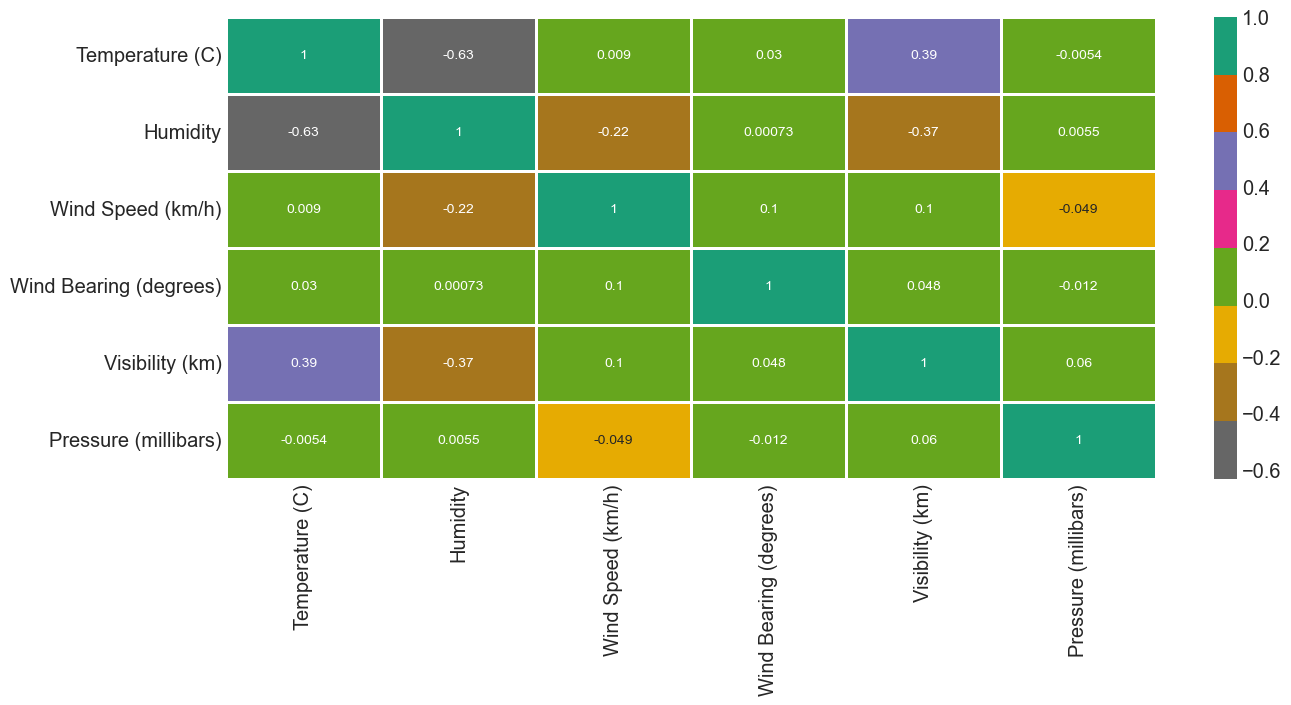

In [16]:
sns.heatmap(data=data_df[num_cols].corr(), annot=True, cmap='Dark2_r', linewidths=2)

In [17]:
time_step = 24

y_idx = np.arange(time_step, temp_df.shape[0], time_step)
y_df = temp_df.iloc[y_idx]

print(y_df.shape)

(4018, 4)


In [18]:
X_df = temp_df.iloc[ range(len(y_df) * time_step)]
print(X_df.shape)
X_temp = np.reshape(X_df['temp'].to_numpy(), (len(y_df), time_step))
X_hum = np.reshape(X_df['hum'].to_numpy(), (len(y_df), time_step))
X_viz = np.reshape(X_df['viz'].to_numpy(), (len(y_df), time_step))

X_temp = X_temp[ : ,:23]
X_hum = X_hum[ : ,:23]
X_viz = X_viz[ : ,:23]

print(X_temp.shape)

(96432, 4)
(4018, 23)


In [19]:
X_data = np.stack((X_temp, 
                   X_hum, 
                #    X_viz
                   ), axis=2) # samples, timesteps, features
print(X_data.shape)

(4018, 23, 2)


In [20]:
split = int(y_df.shape[0] * (1 - TEST_SIZE))
X_train = X_data[:split]
X_test = X_data[split:]
y_train = y_df['temp'].to_numpy()[:split]
y_test = y_df['temp'].to_numpy()[split:]

X_train.shape , X_test.shape ,y_train.shape, y_test.shape

((3214, 23, 2), (804, 23, 2), (3214,), (804,))

In [21]:
h_units = 512

input_shape = (time_step-1, X_train.shape[2])

model = tf.keras.Sequential()
model.add(tf.keras.Input(shape=input_shape))
model.add(tf.keras.layers.SimpleRNN(units=h_units, activation='tanh'))
model.add(tf.keras.layers.Dense(1, activation='linear'))

In [22]:
wax = model.get_weights()[0].shape
waa = model.get_weights()[1].shape
baa = model.get_weights()[2].shape
way = model.get_weights()[3].shape
bay = model.get_weights()[4].shape


In [23]:
loss_fn = tf.keras.losses.MeanSquaredError()
optimizer = tf.keras.optimizers.Adam(learning_rate=ALPHA)
metrics = tf.keras.metrics.RootMeanSquaredError()
model.compile(optimizer=optimizer, loss=loss_fn, metrics=[metrics])

In [24]:
LR_FACTOR = 0.1
LR_PATIENCE = 5
PATIENCE = 20
MIN_LR = 1e-6

#Call Back:
tb_callback = tf.keras.callbacks.TensorBoard(log_dir='logs')

es_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    verbose=1,
    restore_best_weights=True
)

lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
    verbose=1,
    mode='auto',
    min_lr=MIN_LR
)

In [25]:
hist = model.fit(X_train, y_train, 
                 validation_data=[X_test,y_test], 
                 callbacks=[es_callback, lr_callback],
                 batch_size=BATCH_SIZE,
                 epochs=EPOCHS)

Epoch 1/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 6.1764 - root_mean_squared_error: 2.4852 - val_loss: 1.8481 - val_root_mean_squared_error: 1.3595 - learning_rate: 0.0010
Epoch 2/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 1.5692 - root_mean_squared_error: 1.2527 - val_loss: 0.9004 - val_root_mean_squared_error: 0.9489 - learning_rate: 0.0010
Epoch 3/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 1.3594 - root_mean_squared_error: 1.1660 - val_loss: 0.7773 - val_root_mean_squared_error: 0.8817 - learning_rate: 0.0010
Epoch 4/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 1.2691 - root_mean_squared_error: 1.1265 - val_loss: 0.7943 - val_root_mean_squared_error: 0.8913 - learning_rate: 0.0010
Epoch 5/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 2.0650 - root_mean_squared_error: 1.4370 - val_loss: 0.9235 - val_root_mean_squared_error: 0.9610 - learning_rate: 0.0010
Epoch 6/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 1.2877 - root_mean

In [26]:
y_pred_train = model(X_train).numpy()
y_pred_test = model(X_test).numpy()
y_pred = np.append(y_pred_train, y_pred_test)

res_df = y_df.copy()
res_df['pred'] = y_pred
res_df['datetime'] = res_df['datetime'].dt.date
res_df.head()

,datetime,temp,hum,viz,pred
24,2006-01-01,5.422222,0.86,15.6492,4.90629
48,2006-01-02,1.694444,0.92,4.4919,1.61136
72,2006-01-03,2.200000,0.89,9.5795,2.00361
96,2006-01-04,1.666667,0.92,9.9015,1.91403
120,2006-01-05,1.805556,0.99,2.2057,2.38341


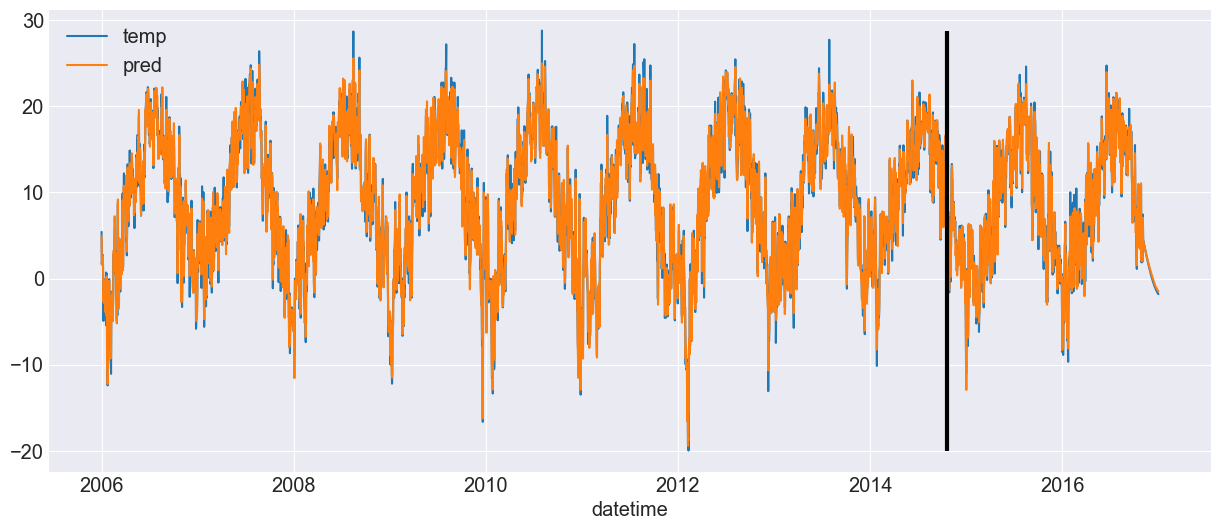

In [27]:
ax = res_df.plot(x='datetime', y=['temp','pred'])
ax.vlines(res_df.iloc[X_train.shape[0]]['datetime'], 
          res_df['temp'].min(),
          res_df['temp'].max(),
          color='k',
          linewidth=3)

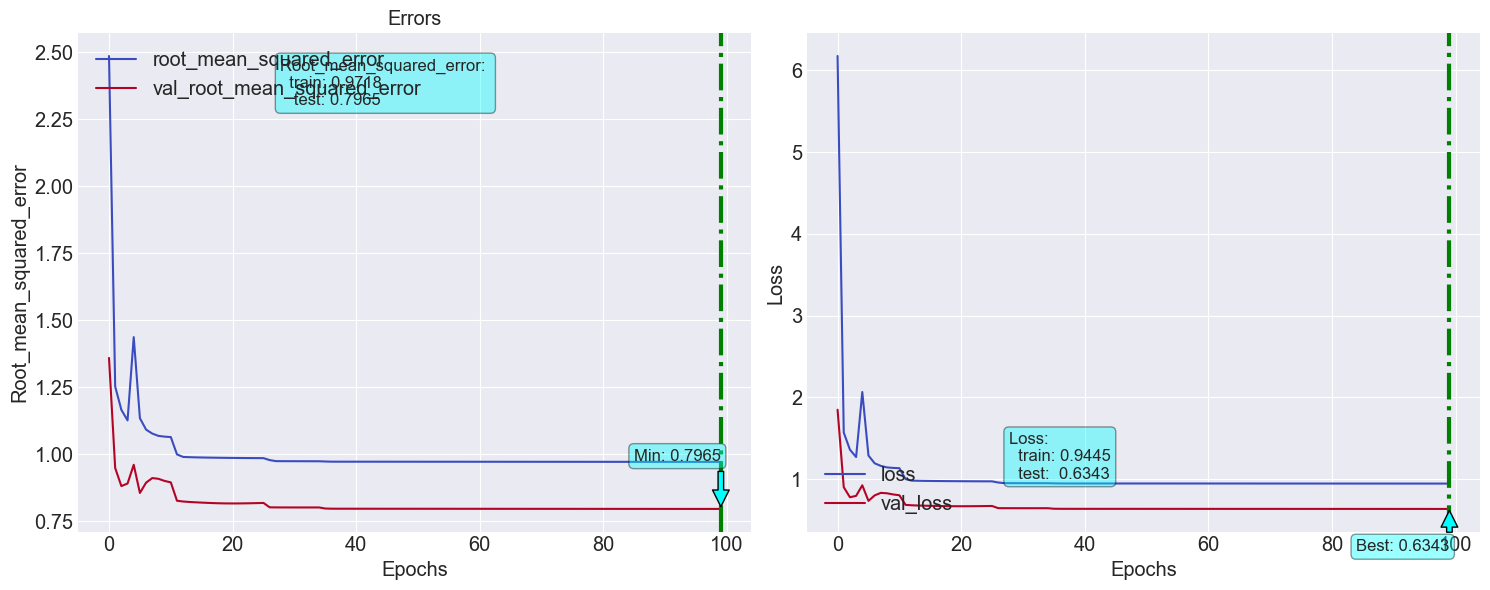

In [28]:
loss_df = pd.DataFrame(hist.history)
fn_plot_tf_hist(loss_df)

0.656 loss using all 3 <br>
0.6292 : temp + viz <br>
0.6597 : temp + hum


<Axes: xlabel='datetime'>

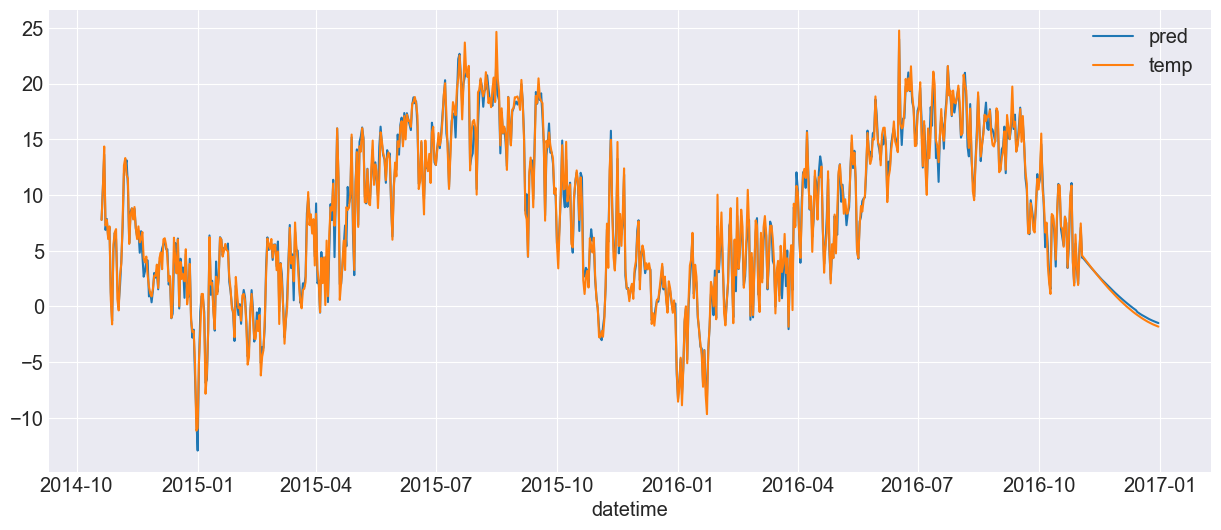

In [29]:
res_df.iloc[X_train.shape[0]:].plot(x='datetime',y=['pred','temp'])